In [1205]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import plotly.express as px
from matplotlib.ticker import FuncFormatter


In [1206]:
dataframe = pd.read_csv('medical-charges.csv')

In [1207]:
df = dataframe.copy()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [1208]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
columns = df[['sex','smoker','region']]
encoded_columns = encoder.fit_transform(columns).toarray()
new_df = pd.DataFrame(encoded_columns,columns=encoder.get_feature_names_out(),index=df.index)
final_df = pd.concat([df.drop(labels=columns,axis=1),new_df],axis=1)
df = final_df

<Axes: >

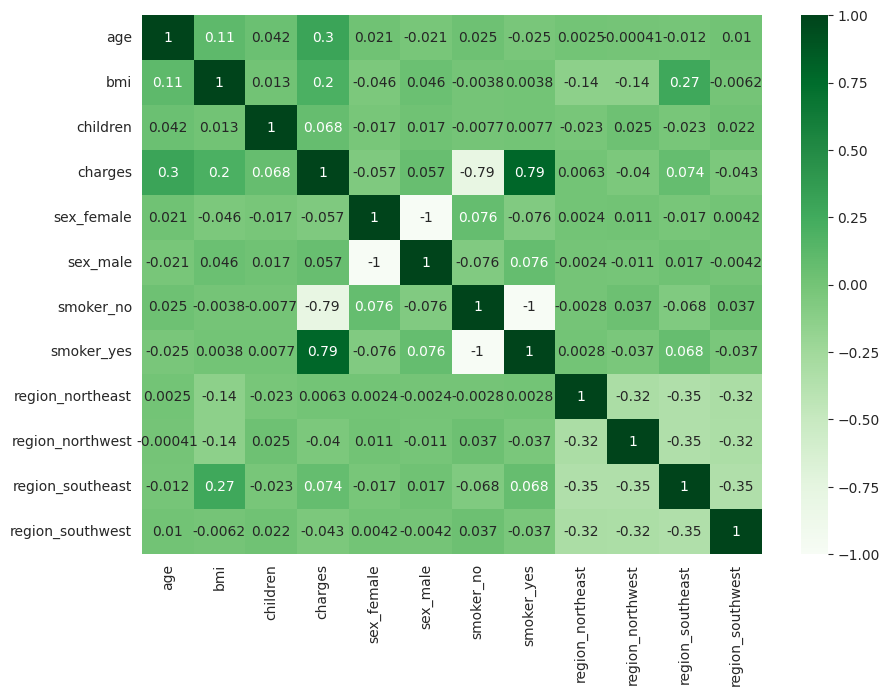

In [1209]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),cmap='Greens',annot=True)

Root Mean Squared Error: 7530.8833153938485
R2 Score: 0.6129853088820014


<Axes: xlabel='age', ylabel='charges'>

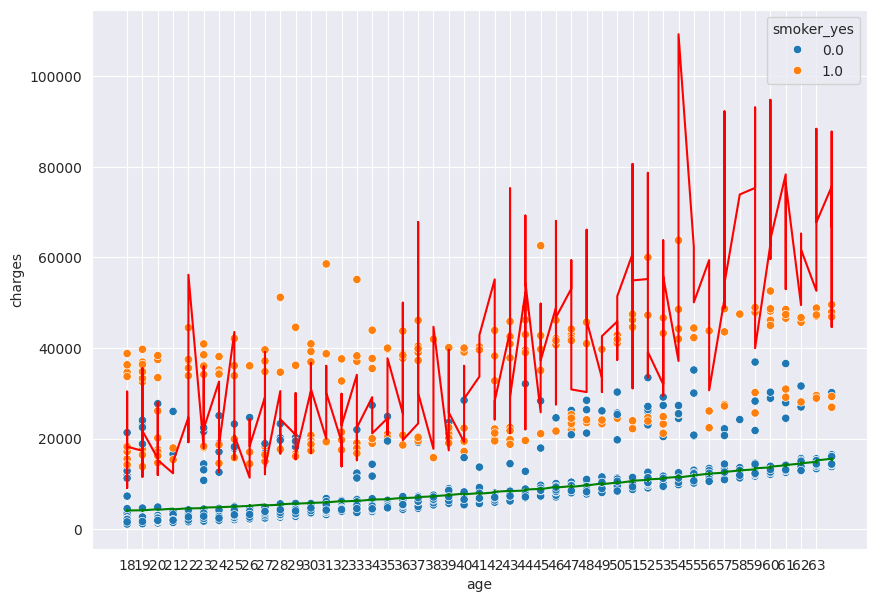

In [1210]:
from sklearn.linear_model import GammaRegressor
from sklearn.metrics import root_mean_squared_error,r2_score
model = GammaRegressor()
df ['bmi_smoker'] = df['bmi'] * df['smoker_yes']
inputs = df[['age','bmi','smoker_yes','bmi_smoker']]
targets = df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
df['predicted_charges'] = pred
rmse = root_mean_squared_error(targets,pred)
r2_results = r2_score(targets,pred)

print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2_results}")
non_smoker_df = df[df['smoker_no']==1].sort_values(by='age')
smoker_df = df[df['smoker_yes']==1].sort_values(by='age')


plt.figure(figsize=(10,7))
plt.xticks(range(18,64))
plt.plot(non_smoker_df['age'],non_smoker_df['predicted_charges'],'g')
plt.plot(smoker_df['age'],smoker_df['predicted_charges'],'r')
sns.scatterplot(data=df,x='age',y=targets,hue='smoker_yes')



Root Mean Squared Error: 4367.177347912711
R2 Score: 0.869852068140384


<Axes: xlabel='age', ylabel='charges'>

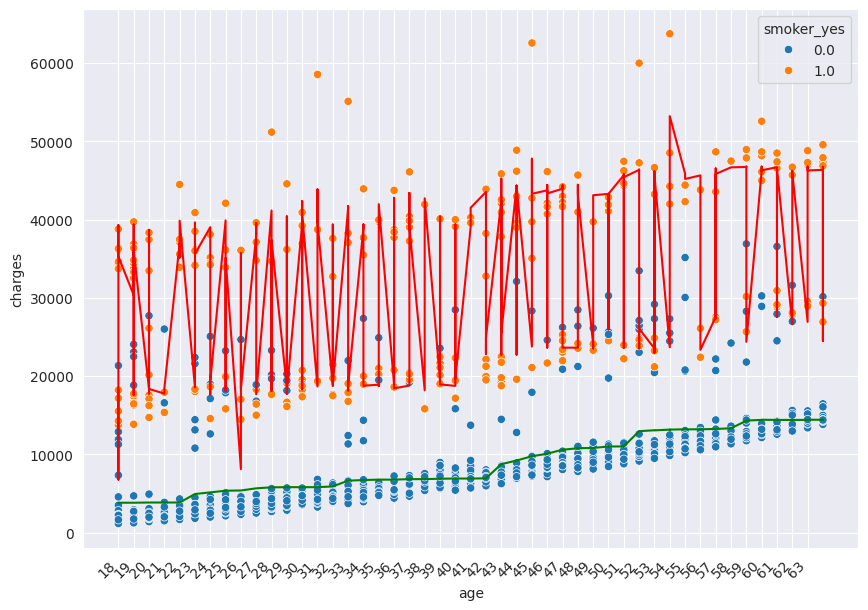

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error,r2_score
model = RandomForestRegressor(n_estimators=150,max_depth=4,random_state=42)
df ['bmi_smoker'] = df['bmi'] * df['smoker_yes']
inputs = df[['age','bmi','sex_female','sex_male','smoker_yes','bmi_smoker']]
targets = df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
df['predicted_charges'] = pred
rf_rmse = root_mean_squared_error(targets,pred)
rf_r2_results = r2_score(targets,pred)

print(f"Root Mean Squared Error: {rf_rmse}")
print(f"R2 Score: {rf_r2_results}")
non_smoker_df = df[df['smoker_no']==1].sort_values(by='age')
smoker_df = df[df['smoker_yes']==1].sort_values(by='age')


plt.figure(figsize=(10,7))
plt.xticks(range(18,64))
plt.xticks(rotation=45,ha='right')
plt.plot(non_smoker_df['age'],non_smoker_df['predicted_charges'],'g')
plt.plot(smoker_df['age'],smoker_df['predicted_charges'],'r')
sns.scatterplot(data=df,x='age',y=targets,hue='smoker_yes')

<Axes: xlabel='age', ylabel='charges'>

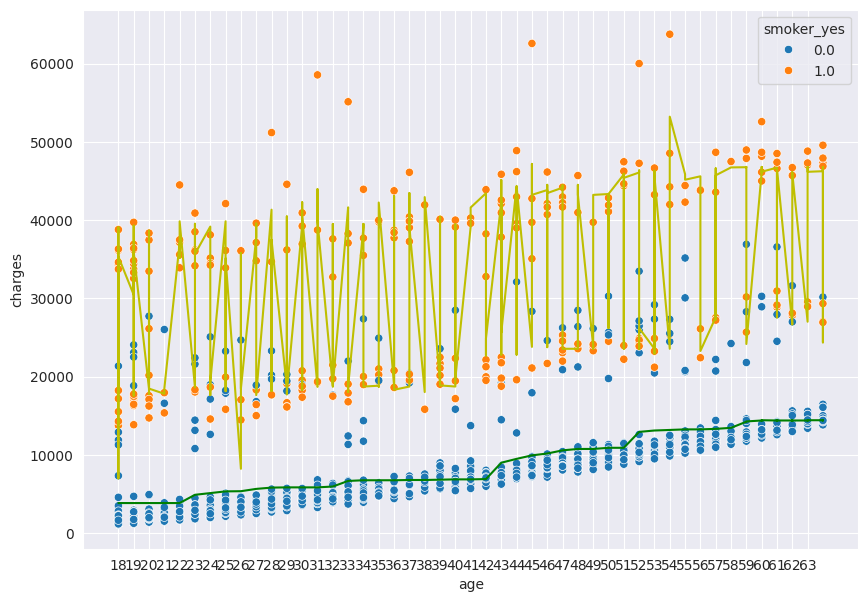

In [1240]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error,r2_score
model = RandomForestRegressor(n_estimators=100,max_depth=4,random_state=42)
inputs = df[['age','bmi','smoker_yes','bmi_smoker']]
targets = df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
df['predicted_charges'] = pred
r2_score_result = r2_score(targets,pred)
rmse_result = root_mean_squared_error(targets,pred)

non_smoker_df = df[df['smoker_no']==1].sort_values(by='age')
smoker_df = df[df['smoker_yes']==1].sort_values(by='age')

r2_score_result, rmse_result
plt.figure(figsize=(10,7))
plt.xticks(range(18,64))
plt.plot(non_smoker_df['age'],non_smoker_df['predicted_charges'],'g')
plt.plot(smoker_df['age'],smoker_df['predicted_charges'],'y')
sns.scatterplot(data=df,x=df['age'],y=df['charges'],hue='smoker_yes')